In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## to show the type of the (df)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## to pring a random Values (number of the values i want to see)

In [5]:
df.sample(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5347,9788-HNGUT,Male,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.95,8594.4,No
4250,0565-JUPYD,Male,0,No,No,63,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,No,One year,No,Credit card (automatic),104.50,6590.8,No
4741,6583-KQJLK,Female,1,Yes,No,15,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.65,1285.05,No
4957,4486-EFAEB,Male,0,No,No,13,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,20.40,251.65,No
3999,5276-KQWHG,Female,1,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,131.65,Yes
3983,1334-FJSVR,Male,0,No,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.25,24.25,Yes
6364,9717-IOAAF,Male,0,No,Yes,27,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.85,788.55,No
4041,5862-BRIXZ,Male,0,No,No,46,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),60.75,2893.4,No
4849,8190-ZTQFB,Male,0,No,No,41,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,One year,Yes,Electronic check,51.35,2075.1,No
5107,9633-DENPU,Female,0,Yes,No,47,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),58.60,2723.4,No


## to understand the type of the df (Categorys or Stream)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## check if there are a null values

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## to see if there are a duplicated values

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

## to remove the duplicated values

In [9]:
df.drop_duplicates(inplace=True)

## check outliers values

<Axes: >

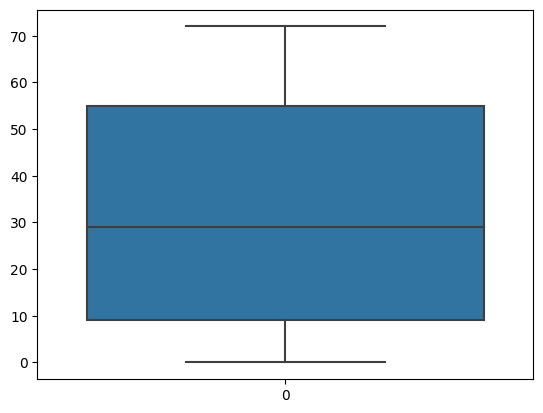

In [10]:
sns.boxplot(df['tenure'])

## check values for male and female in column gender

### df['gender'].value_counts().plot(kind='pie',autopct='');

### choose the column (value_counters()) This part calculates the count of each unique value in the column
### (autopct='%1.1f%%') This property is used to add percentages inside each section of the pie chart

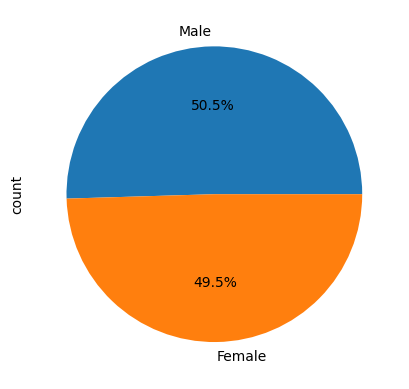

In [11]:
df['gender'].value_counts().plot(kind='pie',autopct='%1.1f%%');

## check if the most client are above or under 65

### most of them are under 56

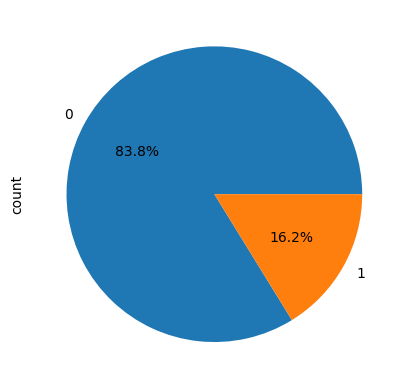

In [12]:
df['SeniorCitizen'].value_counts().plot(kind='pie',autopct='%1.1f%%');

In [13]:
df['SeniorCitizen'].value_counts()


SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

## check the tenure dauration
### Filtering the data from the column (tnure)
### connects the two conditions such that both must be true (the tenure must be between 12 and 24 months).

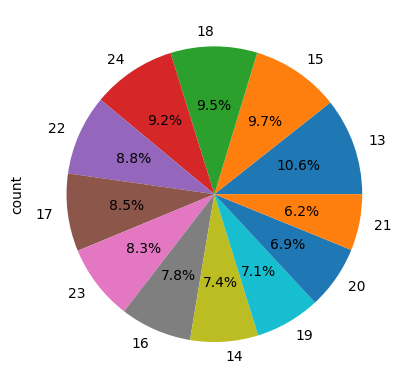

In [14]:
df[(df['tenure'] > 12) & (df['tenure'] <= 24)]['tenure'].value_counts().plot(kind='pie', autopct='%1.1f%%');

# The next 6 steps are almost the same we conclude (y)
### we have x=the Column name , hue(y)=Churn(the Target) , data=df(where is our data) , paletter=the colors

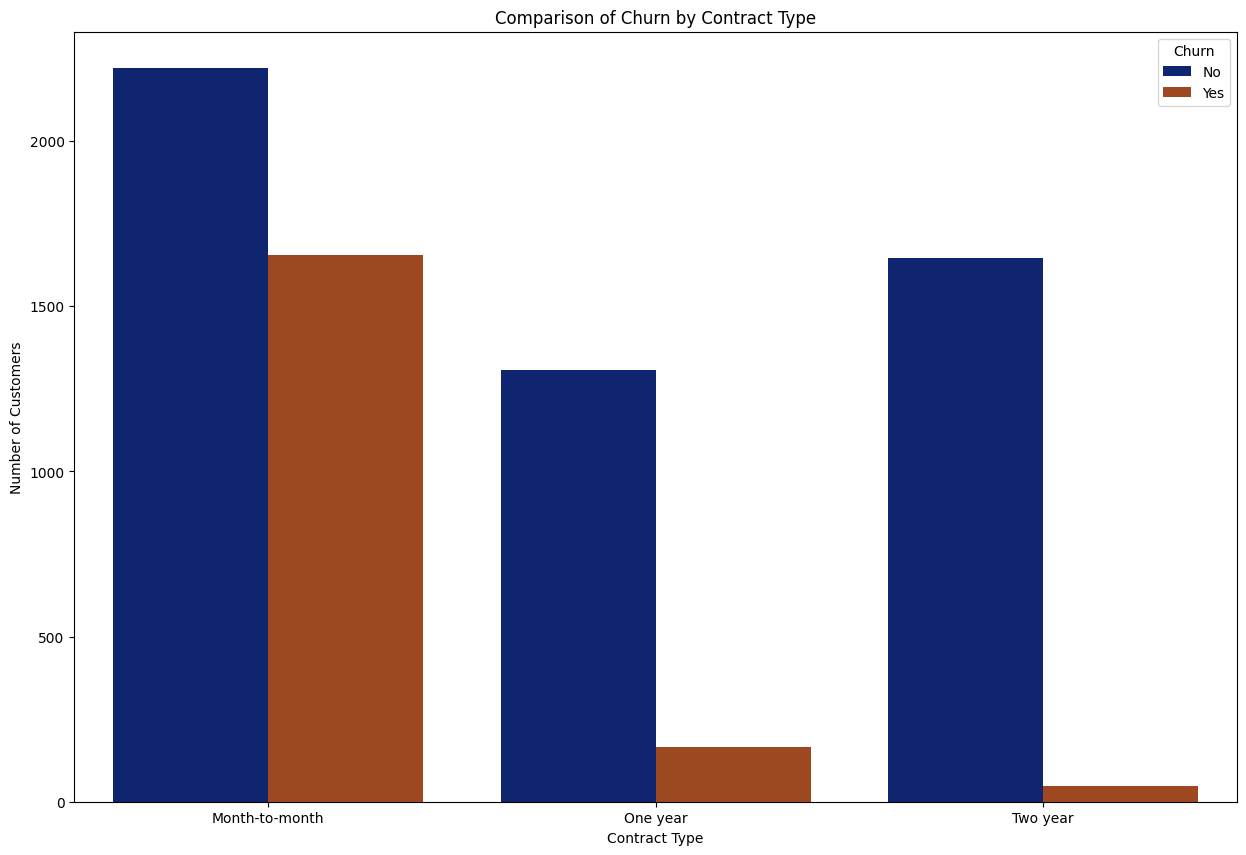

In [15]:
plt.figure(figsize=(15, 10))
sns.countplot(x='Contract', hue='Churn', data=df, palette='dark');
plt.title('Comparison of Churn by Contract Type');
plt.ylabel('Number of Customers');
plt.xlabel('Contract Type');
plt.show();

# in the next step if we swaped bnetween X and Y the visulaisation will appears in  Vertical 

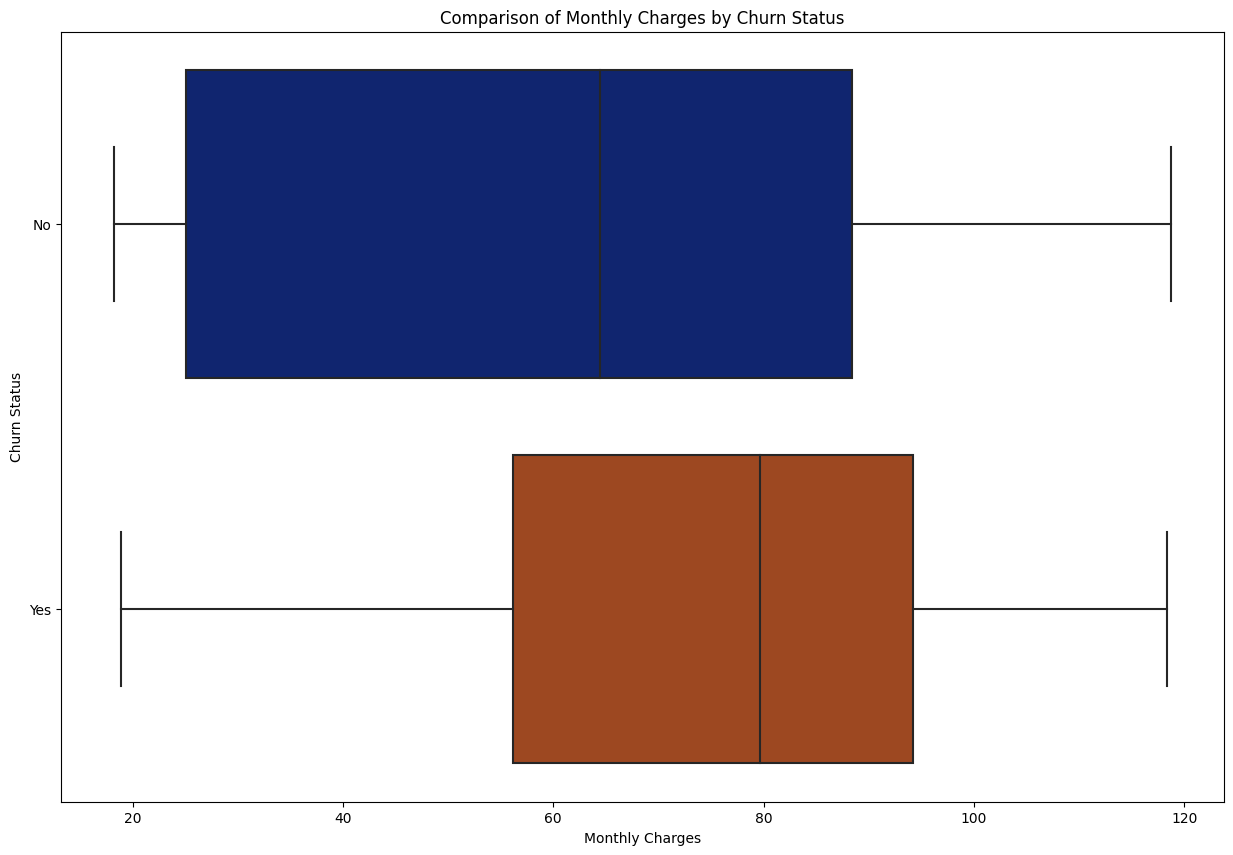

In [16]:
plt.figure(figsize=(15, 10))
sns.boxplot(x='MonthlyCharges', y='Churn', data=df, palette='dark');
plt.title('Comparison of Monthly Charges by Churn Status');
plt.ylabel('Churn Status');
plt.xlabel('Monthly Charges');
plt.show();

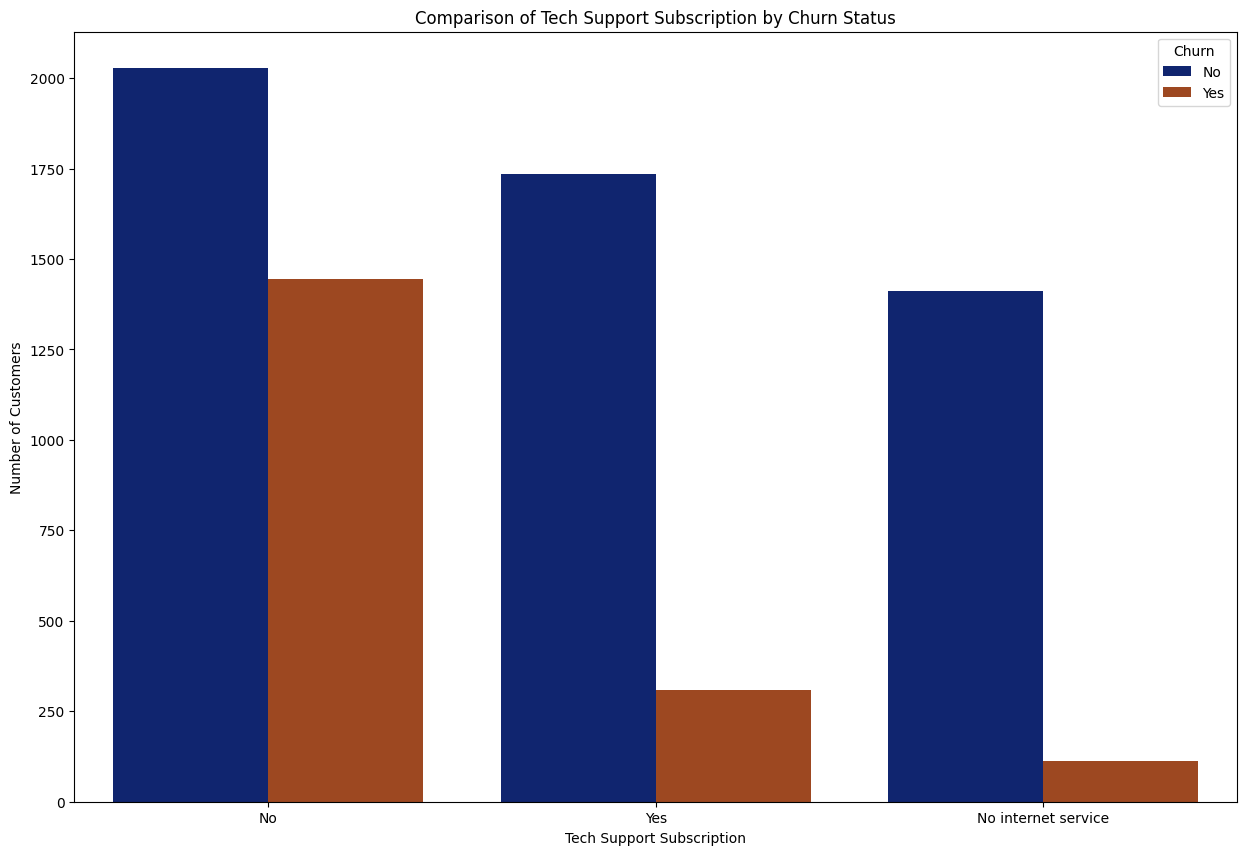

In [17]:
plt.figure(figsize=(15, 10))  
sns.countplot(x='TechSupport', hue='Churn', data=df, palette='dark');
plt.title('Comparison of Tech Support Subscription by Churn Status');
plt.ylabel('Number of Customers');
plt.xlabel('Tech Support Subscription');
plt.show();

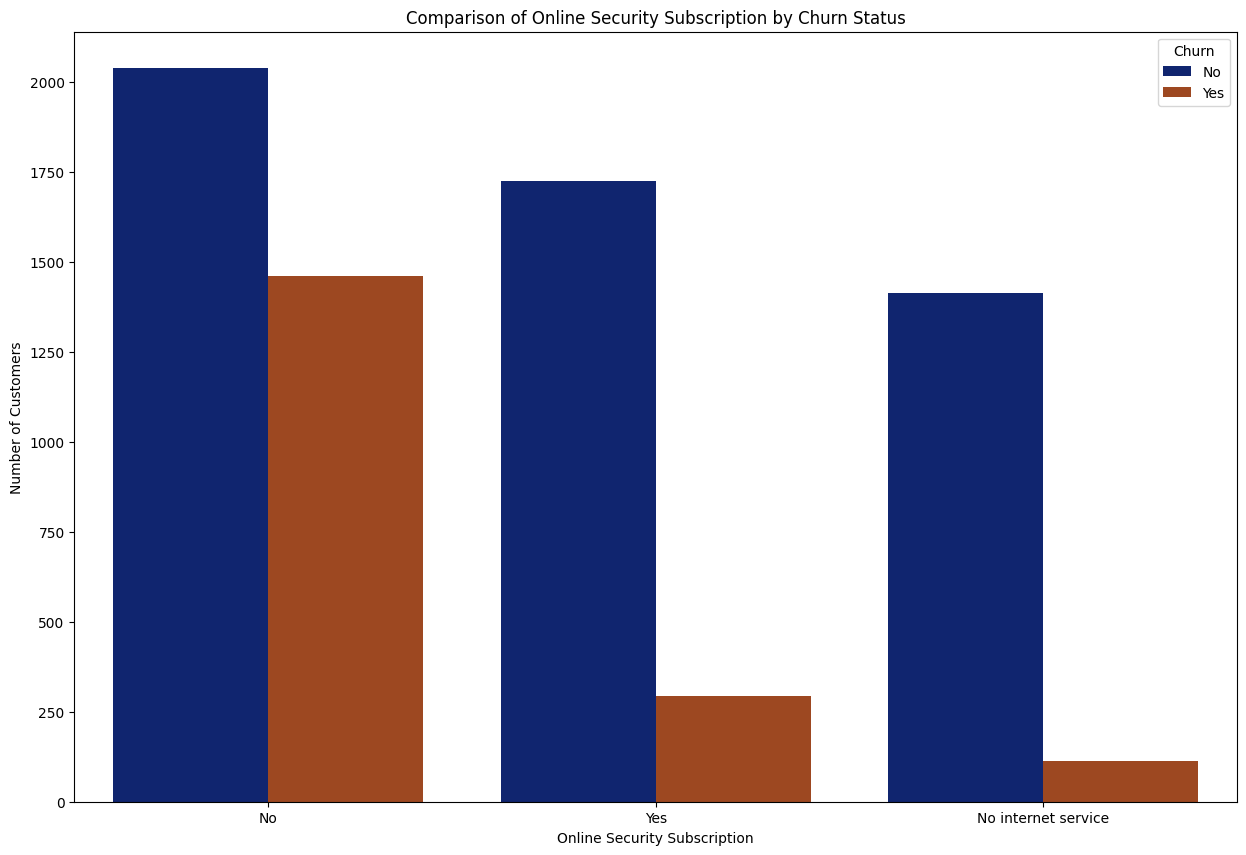

In [18]:
plt.figure(figsize=(15, 10))   
sns.countplot(x='OnlineSecurity', hue='Churn', data=df, palette='dark');
plt.title('Comparison of Online Security Subscription by Churn Status');
plt.ylabel('Number of Customers');
plt.xlabel('Online Security Subscription');
plt.show();

In [19]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

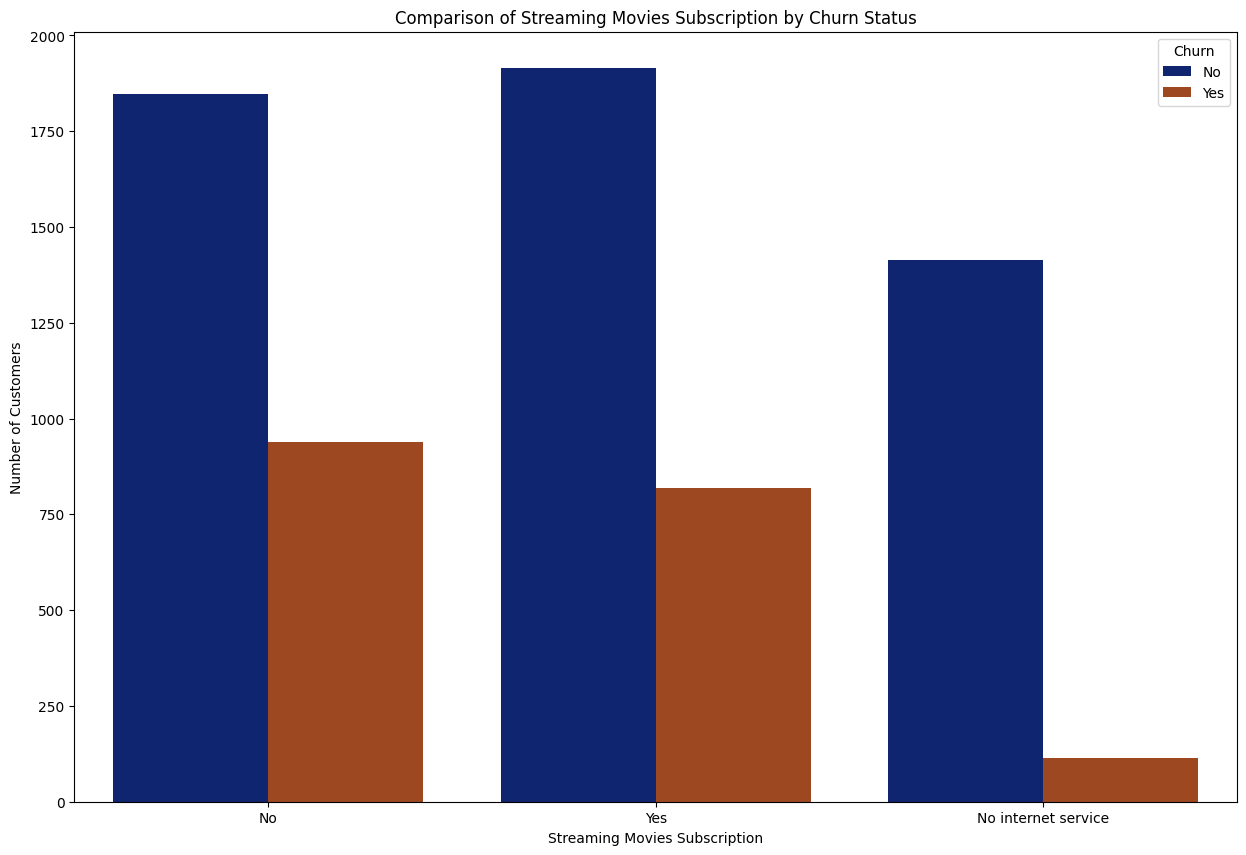

In [20]:
plt.figure(figsize=(15, 10))  
sns.countplot(x='StreamingMovies', hue='Churn', data=df, palette='dark');
plt.title('Comparison of Streaming Movies Subscription by Churn Status');
plt.ylabel('Number of Customers');
plt.xlabel('Streaming Movies Subscription');
plt.show();

In [21]:
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

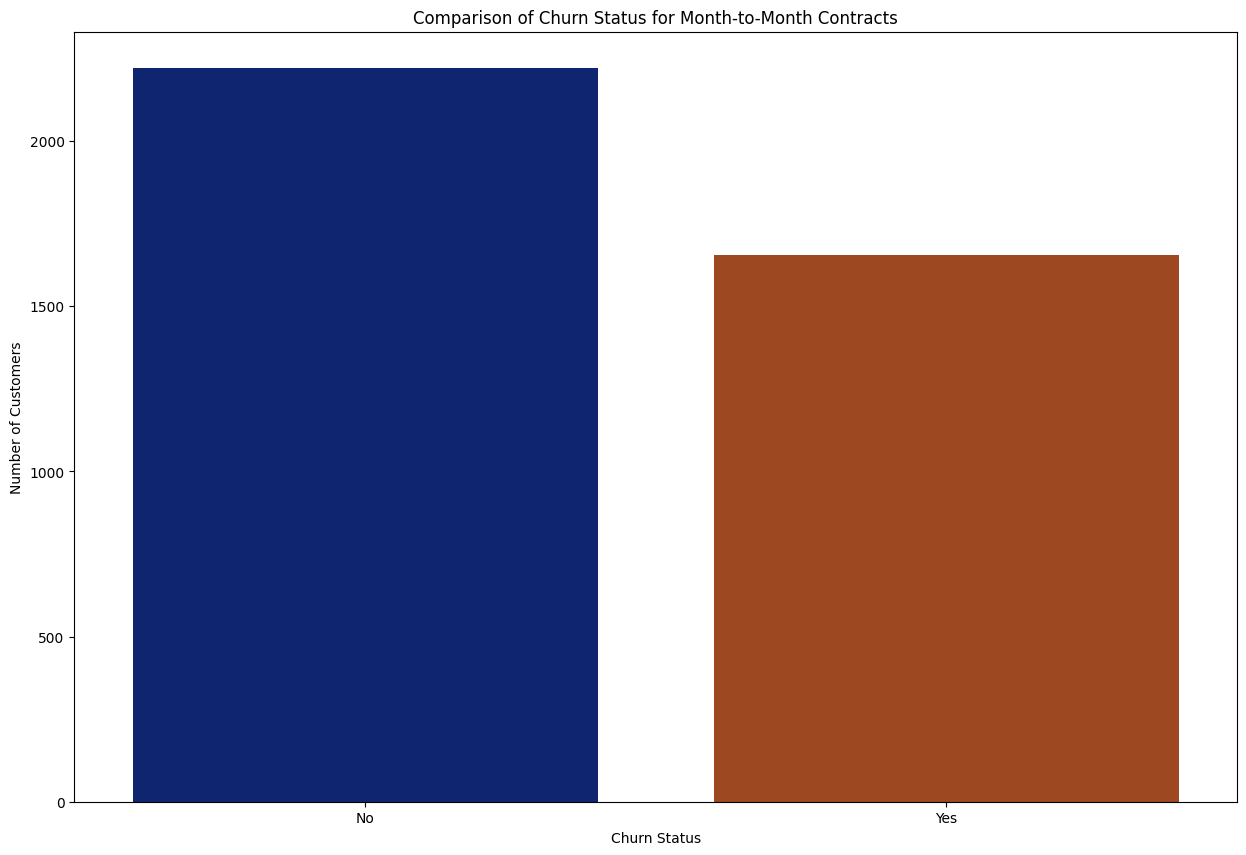

In [22]:
filtered_df = df[df['Contract'] == 'Month-to-month']

plt.figure(figsize=(15, 10)) 
sns.countplot(x='Churn', data=filtered_df, palette='dark');
plt.title('Comparison of Churn Status for Month-to-Month Contracts');
plt.ylabel('Number of Customers');
plt.xlabel('Churn Status');
plt.show();

In [23]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64